Importing Libraries

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Data preprocessing
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


importing the Dataset

In [ ]:
df = pd.read_csv("/content/Students Social Media Addiction.csv")

First 5 Rows of the Dataset

In [ ]:
print(df.head())

   Student_ID  Age  Gender Academic_Level     Country  Avg_Daily_Usage_Hours  \
0           1   19  Female  Undergraduate  Bangladesh                    5.2   
1           2   22    Male       Graduate       India                    2.1   
2           3   20  Female  Undergraduate         USA                    6.0   
3           4   18    Male    High School          UK                    3.0   
4           5   21    Male       Graduate      Canada                    4.5   

  Most_Used_Platform Affects_Academic_Performance  Sleep_Hours_Per_Night  \
0          Instagram                          Yes                    6.5   
1            Twitter                           No                    7.5   
2             TikTok                          Yes                    5.0   
3            YouTube                           No                    7.0   
4           Facebook                          Yes                    6.0   

   Mental_Health_Score Relationship_Status  Conflicts_Over_Soc

Display Dataset Info


In [ ]:
print("Dataset Dimensions:", df_encoded.shape)
print("\n Data Types of Each Column:\n", df_encoded.dtypes)

Dataset Dimensions: (705, 13)

 Data Types of Each Column:
 Age                               int64
Gender                            int64
Academic_Level                    int64
Country                           int64
Avg_Daily_Usage_Hours           float64
Most_Used_Platform                int64
Affects_Academic_Performance      int64
Sleep_Hours_Per_Night           float64
Mental_Health_Score               int64
Relationship_Status               int64
Conflicts_Over_Social_Media       int64
Addicted_Score                    int64
Addiction_Level                  object
dtype: object


 Addiction Score Distribution

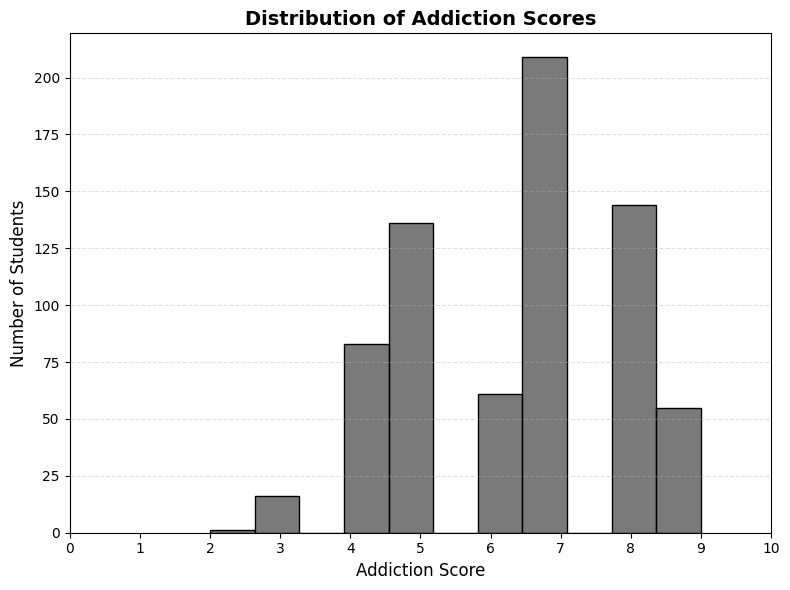

In [ ]:
plt.figure(figsize=(8, 6))


sns.histplot(df['Addicted_Score'], color='#4D4D4D', edgecolor='black')

plt.title("Distribution of Addiction Scores", fontsize=14, weight='bold', color='black')
plt.xlabel("Addiction Score", fontsize=12, color='black')
plt.ylabel("Number of Students", fontsize=12, color='black')

# X-axis ticks for scores 0 to 10
plt.xticks(range(0, 11), color='black')
plt.yticks(color='black')

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


 World Map of Students by Country

In [ ]:
# Count number of unique countries
num_countries = df['Country'].nunique()
print("Number of different countries:", num_countries)

# List the countries present
country_list = df['Country'].unique()
print("Countries represented:", country_list)

# Count number of students by country
country_counts = df['Country'].value_counts().reset_index()
country_counts.columns = ['Country', 'Number_of_Students']

#  Create a world map
fig = px.choropleth(
    country_counts,
    locations='Country',
    locationmode='country names',
    color='Number_of_Students',
    color_continuous_scale=['#f5f5f5', '#bdbdbd', '#4d4d4d'],  # White → gray → black
    title='Distribution of Students by Country'
)


fig.show()


Number of different countries: 110
Countries represented: ['Bangladesh' 'India' 'USA' 'UK' 'Canada' 'Australia' 'Germany' 'Brazil'
 'Japan' 'South Korea' 'France' 'Spain' 'Italy' 'Mexico' 'Russia' 'China'
 'Sweden' 'Norway' 'Denmark' 'Netherlands' 'Belgium' 'Switzerland'
 'Austria' 'Portugal' 'Greece' 'Ireland' 'New Zealand' 'Singapore'
 'Malaysia' 'Thailand' 'Vietnam' 'Philippines' 'Indonesia' 'Taiwan'
 'Hong Kong' 'Turkey' 'Israel' 'UAE' 'Egypt' 'Morocco' 'South Africa'
 'Nigeria' 'Kenya' 'Ghana' 'Argentina' 'Chile' 'Colombia' 'Peru'
 'Venezuela' 'Ecuador' 'Uruguay' 'Paraguay' 'Bolivia' 'Costa Rica'
 'Panama' 'Jamaica' 'Trinidad' 'Bahamas' 'Iceland' 'Finland' 'Poland'
 'Romania' 'Hungary' 'Czech Republic' 'Slovakia' 'Croatia' 'Serbia'
 'Slovenia' 'Bulgaria' 'Estonia' 'Latvia' 'Lithuania' 'Ukraine' 'Moldova'
 'Belarus' 'Kazakhstan' 'Uzbekistan' 'Kyrgyzstan' 'Tajikistan' 'Armenia'
 'Georgia' 'Azerbaijan' 'Cyprus' 'Malta' 'Luxembourg' 'Monaco' 'Andorra'
 'San Marino' 'Vatican City' 'Lie

 Distribution of Students by Gende

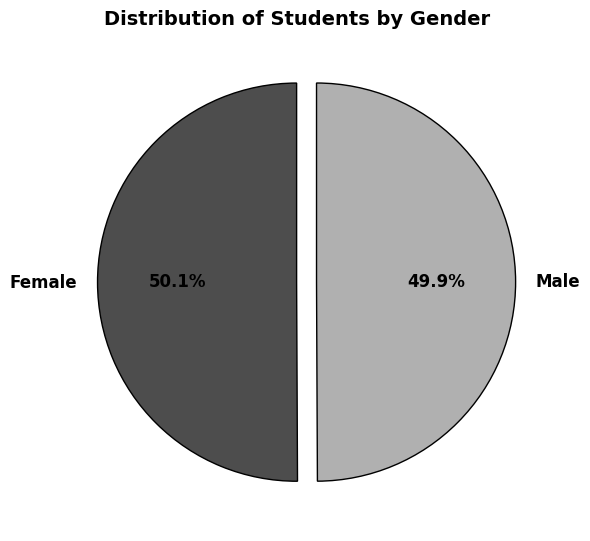

In [ ]:
# Count the number of students by gender
gender_counts = df['Gender'].value_counts()

# Create the pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    explode=(0, 0.1),
    colors=['#4D4D4D', '#B0B0B0'],
    startangle=90,
    textprops={'fontsize': 12, 'weight': 'bold', 'color': 'black'},
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)

# Title
plt.title("Distribution of Students by Gender", fontsize=14, weight='bold', color='black')

# Hide y-axis label and tighten layout
plt.ylabel('')
plt.tight_layout()
plt.show()


Distribution of Students by Relationship Status

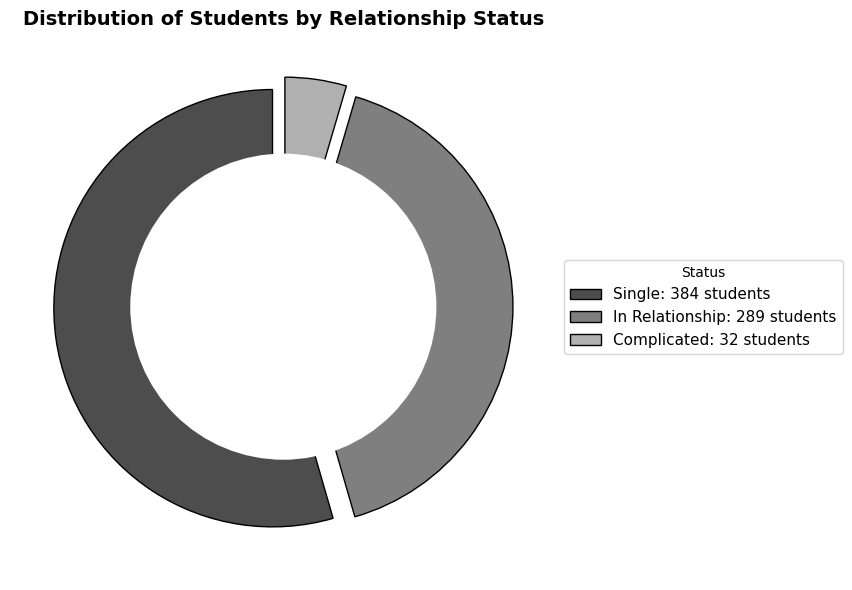

In [ ]:
import matplotlib.pyplot as plt

# Nettoyer les noms de colonnes
df.columns = df.columns.str.strip()

# Compter les valeurs
counts = df['Relationship_Status'].value_counts()

# Couleurs en niveaux de gris
colors = ['#4D4D4D', '#7F7F7F', '#B0B0B0'][:len(counts)]

# Créer la figure
fig, ax = plt.subplots(figsize=(8, 6))

# Tracer le donut (sans autopct donc seulement deux valeurs retournées)
wedges, texts = ax.pie(
    counts,
    labels=None,
    colors=colors,
    explode=[0.05]*len(counts),
    startangle=90,
    textprops={'fontsize': 12},
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)

# Ajouter un cercle blanc pour créer l'effet donut
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Ajouter un titre en anglais
plt.title("Distribution of Students by Relationship Status", fontsize=14, weight='bold', color='black')

# Créer la légende avec les valeurs
legend_labels = [f"{label}: {count} students" for label, count in zip(counts.index, counts)]
plt.legend(wedges, legend_labels, title="Status", loc="center left", bbox_to_anchor=(1, 0.5), fontsize=11)

# Layout propre
plt.tight_layout()
plt.show()


Distribution of Mental Health Scores

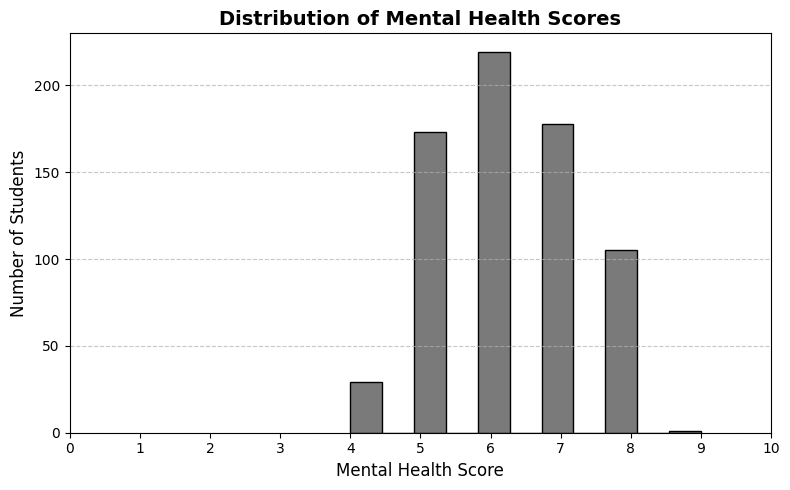

In [ ]:

plt.figure(figsize=(8, 5))

sns.histplot(
    df['Mental_Health_Score'],
    color='#4D4D4D',   # gris foncé
    edgecolor='black',
    bins=11
)


plt.title("Distribution of Mental Health Scores", fontsize=14, weight='bold', color='black')

# Axes
plt.xlabel("Mental Health Score", fontsize=12)
plt.ylabel("Number of Students", fontsize=12)
plt.xticks(range(0, 11))
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


Number of Students per Most Used Platform

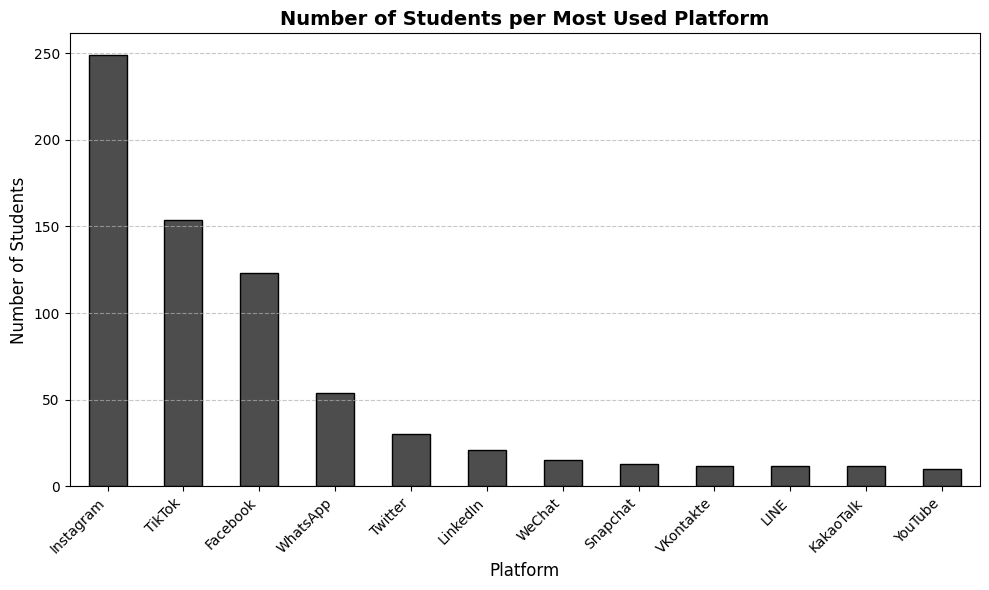

In [ ]:
df.columns = df.columns.str.strip()

# Count students per platform
platform_counts = df['Most_Used_Platform'].value_counts()

# Plot the bar chart
plt.figure(figsize=(10, 6))
platform_counts.plot(
    kind='bar',
    color='#4D4D4D',
    edgecolor='black'
)


plt.title("Number of Students per Most Used Platform", fontsize=14, weight='bold', color='black')
plt.xlabel("Platform", fontsize=12)
plt.ylabel("Number of Students", fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show()


 Number of Students by Academic Level

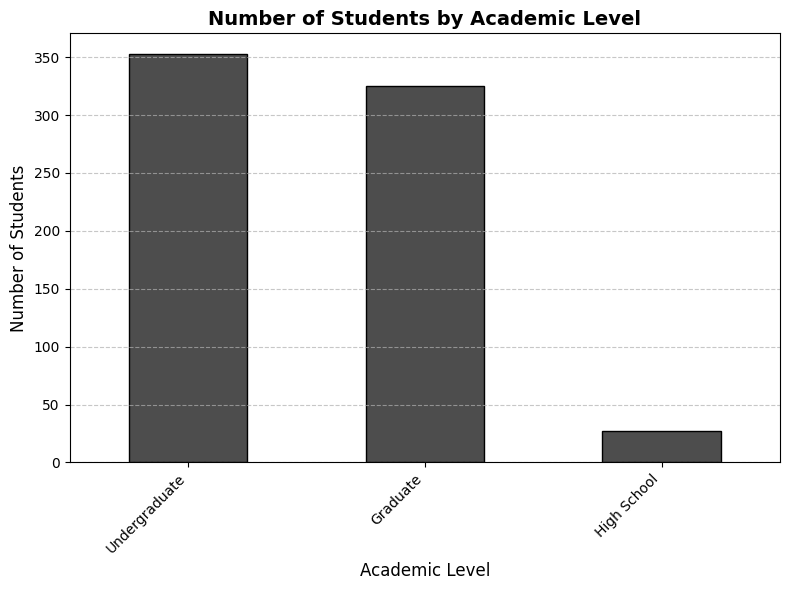

In [ ]:
df.columns = df.columns.str.strip()

# Count number of students per academic level
level_counts = df['Academic_Level'].value_counts()

plt.figure(figsize=(8, 6))
level_counts.plot(
    kind='bar',
    color='#4D4D4D',
    edgecolor='black'
)


plt.title("Number of Students by Academic Level", fontsize=14, weight='bold', color='black')
plt.xlabel("Academic Level", fontsize=12)
plt.ylabel("Number of Students", fontsize=12)


plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show()


Cleaning Data

Step 1: Clean Column Names

In [ ]:
df.columns = df.columns.str.strip()  # Removes leading and trailing spaces from column names


Step 2 : Check Column Data Types

In [ ]:
print(df.dtypes)

Student_ID                        int64
Age                               int64
Gender                           object
Academic_Level                   object
Country                          object
Avg_Daily_Usage_Hours           float64
Most_Used_Platform               object
Affects_Academic_Performance     object
Sleep_Hours_Per_Night           float64
Mental_Health_Score               int64
Relationship_Status              object
Conflicts_Over_Social_Media       int64
Addicted_Score                    int64
dtype: object


Step 3 : Check for Missing Values

In [ ]:
print(df.isnull().sum())

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
Addicted_Score                  0
dtype: int64


 Step 4 :Remove Duplicate Rows

In [ ]:
df.duplicated().sum()  # Count how many duplicated rows exist
df = df.drop_duplicates()  # Remove the duplicated rows

 Step5: Summary Statistics of the Dataset

In [ ]:
df.describe()

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
count,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000
mean,353.000000,20.659574,4.918723,6.868936,6.226950,2.849645,6.436879
std,203.660256,1.399217,1.257395,1.126848,1.105055,0.957968,1.587165
min,1.000000,18.000000,1.500000,3.800000,4.000000,0.000000,2.000000
25%,177.000000,19.000000,4.100000,6.000000,5.000000,2.000000,5.000000
50%,353.000000,21.000000,4.800000,6.900000,6.000000,3.000000,7.000000
75%,529.000000,22.000000,5.800000,7.700000,7.000000,4.000000,8.000000
max,705.000000,24.000000,8.500000,9.600000,9.000000,5.000000,9.000000


 Label Encoding of Categorical Columns

In [ ]:
#  Select categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

# Initialize dictionaries to store encoders and value mappings
encoders = {}
mappings = {}

#  Create a copy of the DataFrame to encode
df_encoded = df.copy()

#  Encode each categorical column
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le
    mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

#  Display mappings for each encoded column
for col, mapping in mappings.items():
    print(f"\nMapping for column '{col}':")
    for k, v in mapping.items():
        print(f"  '{k}' → {v}")

# save the encoded dataset to a CSV file
df_encoded.to_csv("encoded_dataset.csv", index=False)



Categorical columns: ['Gender', 'Academic_Level', 'Country', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Relationship_Status']

Mapping for column 'Gender':
  'Female' → 0
  'Male' → 1

Mapping for column 'Academic_Level':
  'Graduate' → 0
  'High School' → 1
  'Undergraduate' → 2

Mapping for column 'Country':
  'Afghanistan' → 0
  'Albania' → 1
  'Andorra' → 2
  'Argentina' → 3
  'Armenia' → 4
  'Australia' → 5
  'Austria' → 6
  'Azerbaijan' → 7
  'Bahamas' → 8
  'Bahrain' → 9
  'Bangladesh' → 10
  'Belarus' → 11
  'Belgium' → 12
  'Bhutan' → 13
  'Bolivia' → 14
  'Bosnia' → 15
  'Brazil' → 16
  'Bulgaria' → 17
  'Canada' → 18
  'Chile' → 19
  'China' → 20
  'Colombia' → 21
  'Costa Rica' → 22
  'Croatia' → 23
  'Cyprus' → 24
  'Czech Republic' → 25
  'Denmark' → 26
  'Ecuador' → 27
  'Egypt' → 28
  'Estonia' → 29
  'Finland' → 30
  'France' → 31
  'Georgia' → 32
  'Germany' → 33
  'Ghana' → 34
  'Greece' → 35
  'Hong Kong' → 36
  'Hungary' → 37
  'Iceland' → 38
  'India' 

Display the encoded Dataset Info

In [ ]:
print(" Encoded Dataset Dimensions:", df_encoded.shape)
print("\n Data Types of Each Column:\n", df_encoded.dtypes)

 Encoded Dataset Dimensions: (705, 13)

 Data Types of Each Column:
 Student_ID                        int64
Age                               int64
Gender                            int64
Academic_Level                    int64
Country                           int64
Avg_Daily_Usage_Hours           float64
Most_Used_Platform                int64
Affects_Academic_Performance      int64
Sleep_Hours_Per_Night           float64
Mental_Health_Score               int64
Relationship_Status               int64
Conflicts_Over_Social_Media       int64
Addicted_Score                    int64
dtype: object


 Correlation with Addiction Score

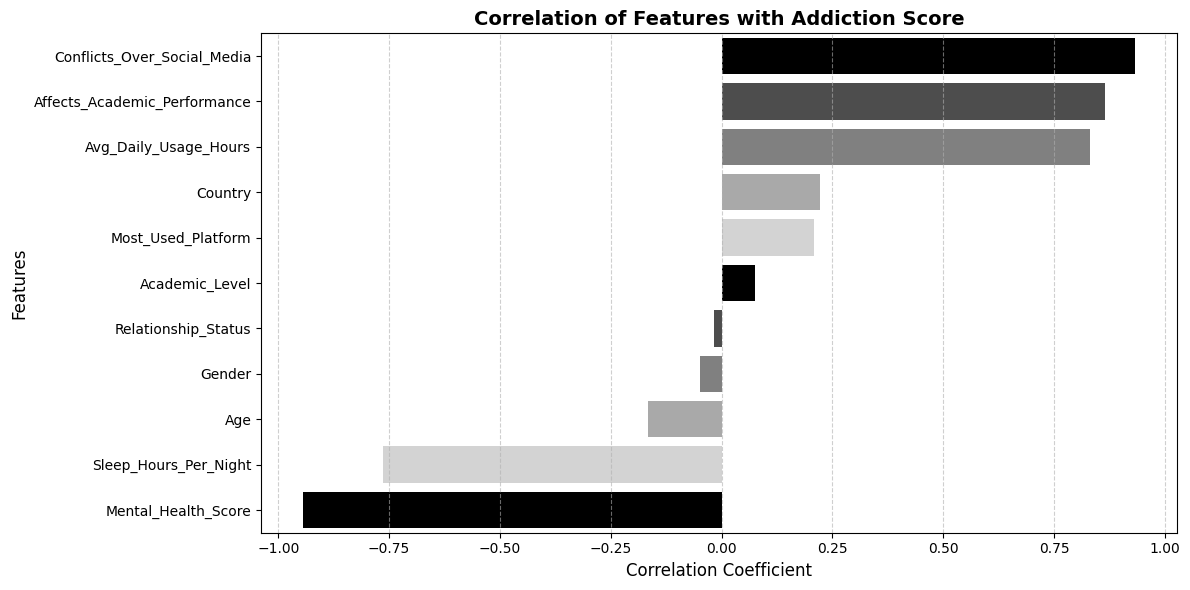

In [ ]:
#  Remove non-informative column
df_encoded.drop(columns=['Student_ID'], inplace=True)

# Compute correlations with the target variable
correlations = df_encoded.corr(numeric_only=True)['Addicted_Score'].sort_values(ascending=False)

# Remove the correlation of the variable with itself
correlations = correlations[correlations.index != 'Addicted_Score']

#  Create the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(
    x=correlations.values,
    y=correlations.index,
    palette=['#000000', '#4D4D4D', '#808080', '#A9A9A9', '#D3D3D3'] * 3  # gray shades
)

#  Titles and labels
plt.title("Correlation of Features with Addiction Score", fontsize=14, weight='bold')
plt.xlabel("Correlation Coefficient", fontsize=12)
plt.ylabel("Features", fontsize=12)


plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Full Correlation Matrix

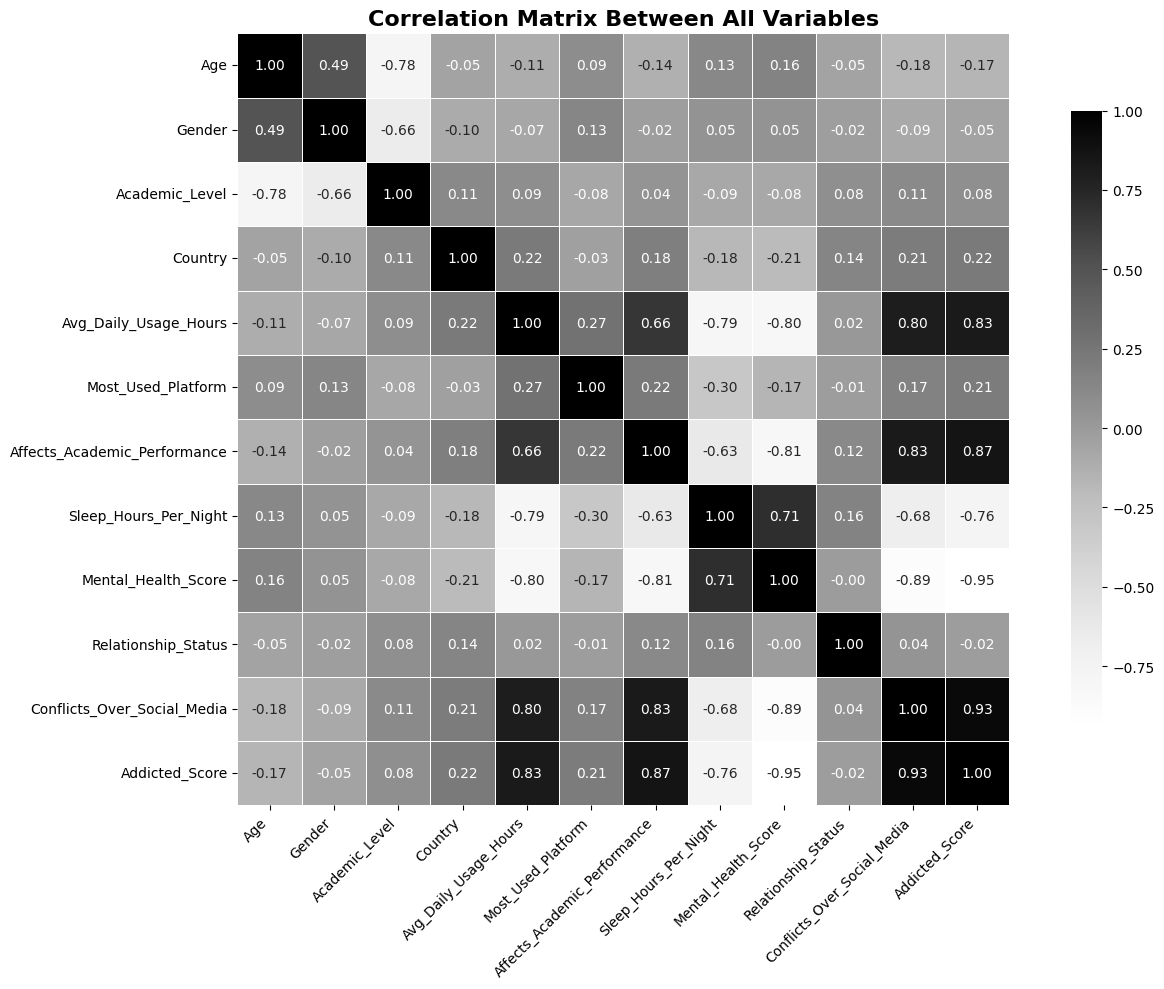

In [ ]:
#  Compute the correlation matrix
correlation_matrix = df_encoded.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='Greys',
    linewidths=0.5,
    cbar_kws={"shrink": .8},
    square=True
)

#  Title and formatting
plt.title('Correlation Matrix Between All Variables', fontsize=16, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Selecting Features Most Correlated with Addiction Score

Features significantly correlated with Addicted_Score:

Conflicts_Over_Social_Media     0.933586
Affects_Academic_Performance    0.866049
Avg_Daily_Usage_Hours           0.832000
Country                         0.221383
Most_Used_Platform              0.209653
Age                            -0.166396
Sleep_Hours_Per_Night          -0.764858
Mental_Health_Score            -0.945051
Name: Addicted_Score, dtype: float64


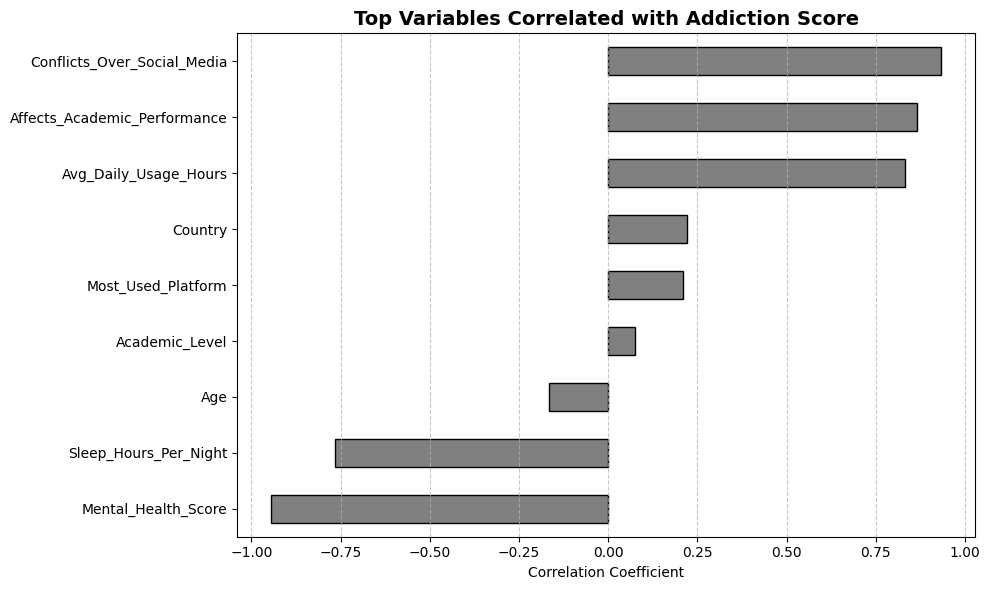

In [ ]:

#  Calculate correlations with the target
correlations = df_encoded.corr(numeric_only=True)['Addicted_Score']

#  Select features with correlation above a threshold
selected_features = correlations[abs(correlations) > 0.1].index.tolist()
selected_features.remove('Addicted_Score')  # Remove the target itself

#  Define X and y for modeling
X = df_encoded[selected_features]
y = df_encoded['Addicted_Score']

#  Print most significant correlations
print("Features significantly correlated with Addicted_Score:\n")
print(correlations[abs(correlations) > 0.1].drop('Addicted_Score').sort_values(ascending=False))

#  Plot the correlations
correlations_selected = correlations[abs(correlations) > 0.05].drop('Addicted_Score').sort_values()

plt.figure(figsize=(10, 6))
correlations_selected.plot(
    kind='barh',
    color='gray',
    edgecolor='black'
)


plt.title("Top Variables Correlated with Addiction Score", fontsize=14, weight='bold')
plt.xlabel("Correlation Coefficient")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



Model 1 : Random Forest Regression

 Random Forest Regression Model

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(" Mean Squared Error:", round(mse, 2))
print("R-squared Score:", round(r2, 2))


 Mean Squared Error: 0.05
R-squared Score: 0.98


 Feature Importance for Predicting Addiction Score

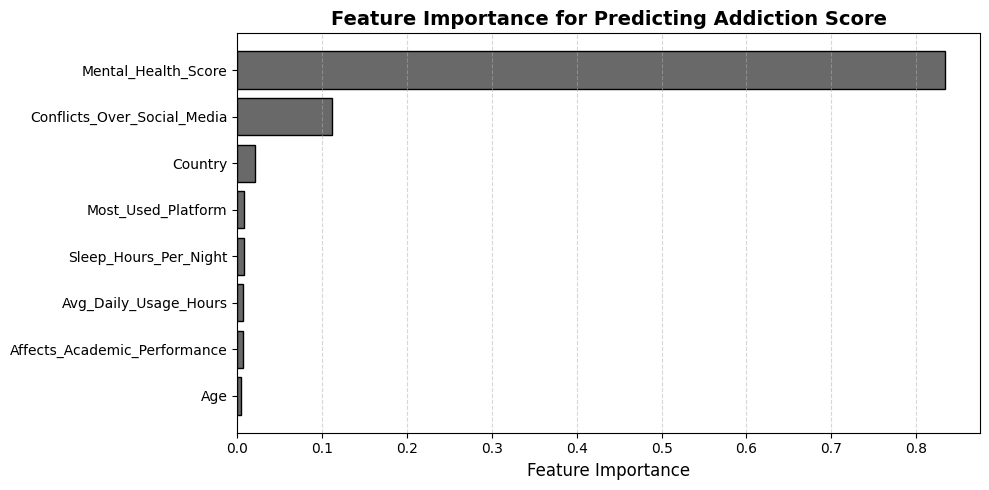

In [ ]:
# Get feature importances and names
importances = model.feature_importances_
features = X.columns

# Sort features for better readability
sorted_idx = importances.argsort()
sorted_features = features[sorted_idx]
sorted_importances = importances[sorted_idx]

plt.figure(figsize=(10, 5))
plt.barh(sorted_features, sorted_importances, color='dimgray', edgecolor='black')

# Add labels and title
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Feature Importance for Predicting Addiction Score', fontsize=14, weight='bold')

# Add grid
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


Model 2 : Random Forest Classifier

Categorize Addiction Score into Levels

In [ ]:
def categorize_score(score):
    if score <= 4:
        return 'Low'
    elif score <= 7:
        return 'Medium'
    else:
        return 'High'

# Apply the function to create a new column
df_encoded['Addiction_Level'] = df_encoded['Addicted_Score'].apply(categorize_score)



Distribution of Students by Addiction Level

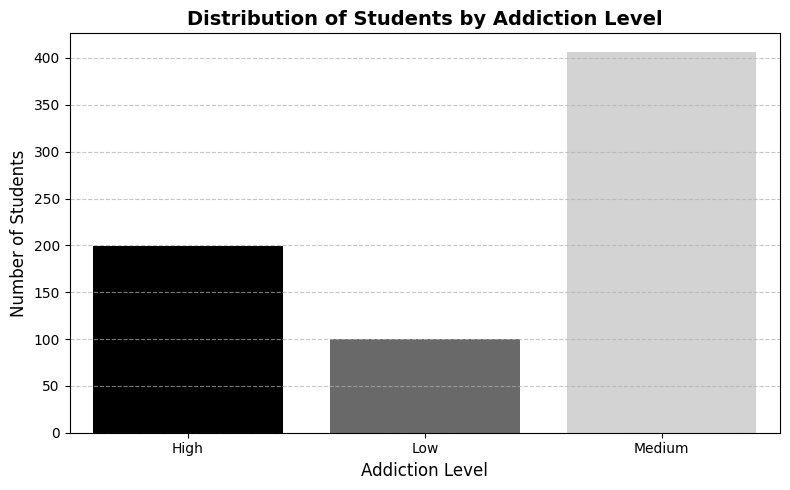

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count number of students in each addiction category
level_counts = df_encoded['Addiction_Level'].value_counts().sort_index()

# Plotting the bar chart in grayscale
plt.figure(figsize=(8, 5))
sns.barplot(
    x=level_counts.index,
    y=level_counts.values,
    palette=['black', 'dimgray', 'lightgray']
)

# Title and axis labels
plt.title("Distribution of Students by Addiction Level", fontsize=14, weight='bold')
plt.xlabel("Addiction Level", fontsize=12)
plt.ylabel("Number of Students", fontsize=12)


plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show()



Class Balance with SMOTE

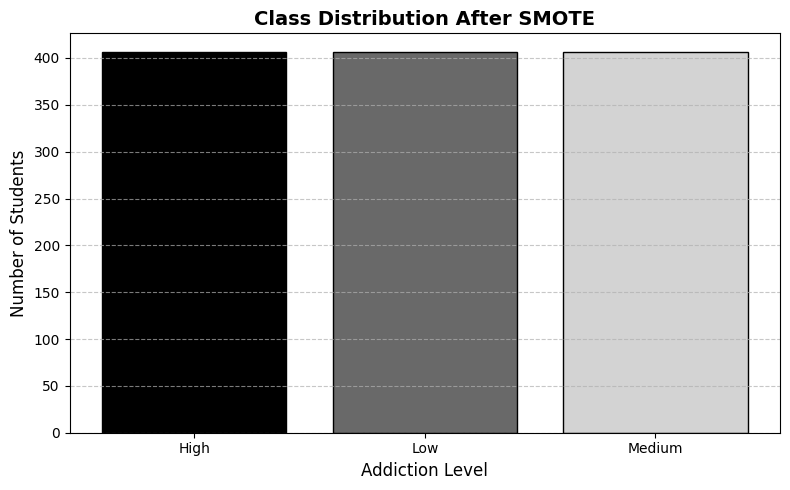

In [ ]:
# Encode target labels
le = LabelEncoder()
y = le.fit_transform(df_encoded['Addiction_Level'])  # 'Low', 'Medium', 'High'
X = df_encoded.drop(columns=['Addicted_Score', 'Addiction_Level'])

# Apply SMOTE to balance classes
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)


y_labels = le.inverse_transform(y_smote)
class_counts = pd.Series(y_labels).value_counts().sort_index()


plt.figure(figsize=(8, 5))
plt.bar(class_counts.index, class_counts.values, color=['black', 'dimgray', 'lightgray'], edgecolor='black')

# Add title and axis labels
plt.title("Class Distribution After SMOTE", fontsize=14, weight='bold')
plt.xlabel("Addiction Level", fontsize=12)
plt.ylabel("Number of Students", fontsize=12)

# Grid and layout
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


 Classification Report:
              precision    recall  f1-score   support

        High       0.99      0.99      0.99        88
         Low       1.00      1.00      1.00        76
      Medium       0.99      0.99      0.99        80

    accuracy                           0.99       244
   macro avg       0.99      0.99      0.99       244
weighted avg       0.99      0.99      0.99       244



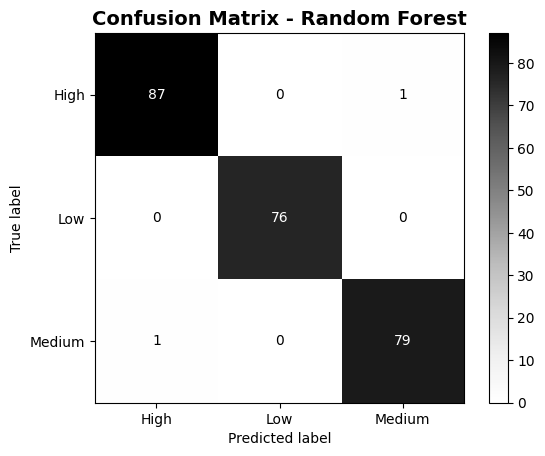

In [ ]:
# 1. Split balanced data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_smote, y_smote, test_size=0.2, random_state=42)

# 2. Initialize and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 3. Make predictions on test set
y_pred = rf_model.predict(X_test)

# 4. Display classification performance
print(" Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 5. Plot confusion matrix in grayscale
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

disp.plot(cmap='Greys')
plt.title("Confusion Matrix - Random Forest", fontsize=14, weight='bold')
plt.grid(False)
plt.show()
